### **What is RAG?**
Retrieval-Augmented Generation (RAG) is the process of optimizing the output of a large language model, so it references an authoritative knowledge base outside of its training data sources before generating a response. Large Language Models (LLMs) are trained on vast volumes of data and use billions of parameters to generate original output for tasks like answering questions, translating languages, and completing sentences. RAG extends the already powerful capabilities of LLMs to specific domains or an organization's internal knowledge base, all without the need to retrain the model. It is a cost-effective approach to improving LLM output so it remains relevant, accurate, and useful in various contexts.

### **Why RAG**?
LLMs are a key artificial intelligence (AI) technology powering intelligent chatbots and other natural language processing (NLP) applications. The goal is to create bots that can answer user questions in various contexts by cross-referencing authoritative knowledge sources. Unfortunately, the nature of LLM technology introduces unpredictability in LLM responses. Additionally, LLM training data is static and introduces a cut-off date on the knowledge it has.

Known challenges of LLMs include:

* Presenting false information when it does not have the answer.
* Presenting out-of-date or generic information when the user expects a specific, current response.
* Creating a response from non-authoritative sources.
* Creating inaccurate responses due to terminology confusion, wherein different training sources use the same terminology to talk about different things.

**RAG is one approach to solving some of these challenges. It redirects the LLM to retrieve relevant information from authoritative, pre-determined knowledge sources. Organizations have greater control over the generated text output, and users gain insights into how the LLM generates the response.**

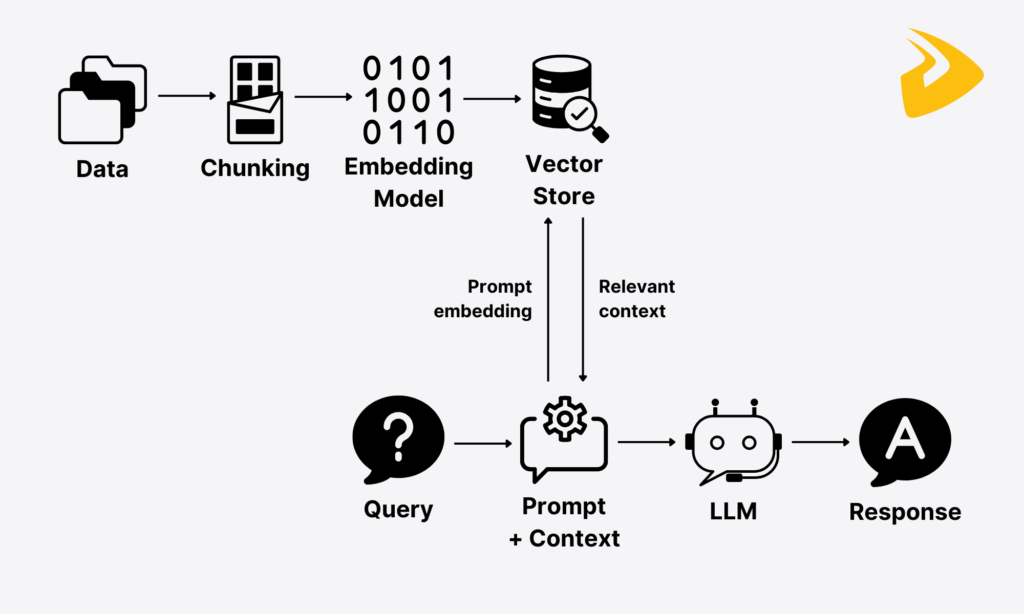

# 🏠 EstateBot — Real Estate RAG Chatbot

An AI-powered chatbot that answers questions about real estate
properties using information stored in Excel files and PDF brochures.


In [1]:
!pip install -q \
    langchain \
    langchain-community \
    langchain-huggingface \
    langchain-text-splitters \
    faiss-cpu \
    pypdf \
    sentence-transformers \
    openpyxl

### Importing Libraries

In [2]:
import os
import pandas as pd

from pathlib import Path

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS

from langchain_huggingface import HuggingFaceEmbeddings

/tmp/ipykernel_33221/3540950248.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


#### Uploading our Real Estate files

In [3]:
from google.colab import files

uploaded = files.upload()

Saving real_estate_properties.xlsx to real_estate_properties (2).xlsx
Saving palm_meadows.pdf to palm_meadows (2).pdf
Saving sunrise_heights.pdf to sunrise_heights (2).pdf
Saving green_valley.pdf to green_valley (2).pdf


In [4]:
import os

os.listdir()

['.config',
 'green_valley (1).pdf',
 'palm_meadows.pdf',
 'real_estate_properties.xlsx',
 'green_valley (2).pdf',
 'real_estate_properties (1).xlsx',
 'sunrise_heights (1).pdf',
 'green_valley.pdf',
 'palm_meadows (2).pdf',
 'real_estate_properties (2).xlsx',
 'sunrise_heights (2).pdf',
 'palm_meadows (1).pdf',
 'sunrise_heights.pdf',
 'sample_data']

#### Loading the Excel data

In [5]:
df = pd.read_excel("real_estate_properties.xlsx")

df.head()

,Property_ID,Property_Name,Location,Property_Type,Configuration,Area_sqft,Price_Cr,Status,Possession,Builder,...,Gym,Swimming_Pool,Parking,Security,Maintenance_per_sqft,Nearby_Schools,Nearby_Hospitals,Metro_Distance,Railway_Distance,Mall_Distance
0,PROP001,Green Valley Residency,Thane West,Apartment,2 BHK,1180,1.28,Ready to Move,2026-11,Aarav Developers,...,Yes,Yes,Yes,24x7 Security,0.80,5,7,850 m,1.2 km,0.9 km
1,PROP002,Sunrise Heights,Andheri East,Apartment,2 BHK,1025,1.62,Under Construction,2027-06,Sunrise Urban Developers,...,Yes,Yes,No,CCTV + Security,1.10,4,8,600 m,2.0 km,1.5 km
2,PROP003,Lakeview Towers,Powai,Apartment,2 BHK,1260,1.88,Ready to Move,2026-09,Lakeview Realty,...,Yes,Yes,Yes,Concierge + Security,1.00,6,10,1.4 km,0.8 km,1.1 km
3,PROP004,Urban Nest,Mulund West,Apartment,2 BHK,1085,1.14,Ready to Move,2026-08,UrbanNest Homes,...,Yes,No,Yes,24x7 Security,0.75,4,6,950 m,1.0 km,0.7 km
4,PROP005,Palm Meadows,Kharghar,Villa,3 BHK,1820,2.15,Ready to Move,2026-10,Meadowline Estates,...,Yes,Yes,Yes,Gated Security,1.25,5,7,1.8 km,1.5 km,1.3 km


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12
Columns: 21


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Property_ID           12 non-null     object 
 1   Property_Name         12 non-null     object 
 2   Location              12 non-null     object 
 3   Property_Type         12 non-null     object 
 4   Configuration         12 non-null     object 
 5   Area_sqft             12 non-null     int64  
 6   Price_Cr              12 non-null     float64
 7   Status                12 non-null     object 
 8   Possession            12 non-null     object 
 9   Builder               12 non-null     object 
 10  Floor                 12 non-null     int64  
 11  Gym                   12 non-null     object 
 12  Swimming_Pool         12 non-null     object 
 13  Parking               12 non-null     object 
 14  Security              12 non-null     object 
 15  Maintenance_per_sqft  12 

In [8]:
df.describe(include="all")

,Property_ID,Property_Name,Location,Property_Type,Configuration,Area_sqft,Price_Cr,Status,Possession,Builder,...,Gym,Swimming_Pool,Parking,Security,Maintenance_per_sqft,Nearby_Schools,Nearby_Hospitals,Metro_Distance,Railway_Distance,Mall_Distance
count,12,12,12,12,12,12.000000,12.000000,12,12,12,...,12,12,12,12,12.000000,12.000000,12.000000,12,12,12
unique,12,12,12,2,3,NaN,NaN,2,12,12,...,1,2,2,5,NaN,NaN,NaN,12,11,10
top,PROP001,Green Valley Residency,Thane West,Apartment,2 BHK,NaN,NaN,Ready to Move,2026-11,Aarav Developers,...,Yes,Yes,Yes,24x7 Security,NaN,NaN,NaN,850 m,1.1 km,1.0 km
freq,1,1,1,11,7,NaN,NaN,9,1,1,...,12,9,9,4,NaN,NaN,NaN,1,2,2
mean,NaN,NaN,NaN,NaN,NaN,1246.250000,1.664167,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.925000,4.333333,6.916667,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,330.014635,1.018988,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.399716,1.154701,1.729862,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,690.000000,0.720000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.450000,3.000000,5.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,1051.250000,0.912500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.625000,3.000000,5.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,1150.000000,1.450000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.850000,4.500000,7.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,1498.750000,1.947500,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.137500,5.000000,8.000000,NaN,NaN,NaN


In [9]:
df["Location"].unique()

array(['Thane West', 'Andheri East', 'Powai', 'Mulund West', 'Kharghar',
       'Ghatkopar East', 'Navi Mumbai', 'Mira Road', 'Worli',
       'Vasai West', 'Chembur', 'Dombivli East'], dtype=object)

In [10]:
df["Configuration"].value_counts()

,count
Configuration,
2 BHK,7
3 BHK,4
1 BHK,1


#### Convert Excel rows into Documents

This is an important RAG concept.

FAISS expects documents/text that can be embedded.

So we'll convert every property row into a natural-language document.

In [11]:
documents = []

for _, row in df.iterrows():

    text = f"""
    Property ID: {row['Property_ID']}
    Property Name: {row['Property_Name']}
    Location: {row['Location']}
    Property Type: {row['Property_Type']}
    Configuration: {row['Configuration']}
    Area: {row['Area_sqft']} sq.ft.
    Price: ₹{row['Price_Cr']} Crore
    Status: {row['Status']}
    Possession: {row['Possession']}
    Builder: {row['Builder']}
    Floor: {row['Floor']}
    Gym: {row['Gym']}
    Swimming Pool: {row['Swimming_Pool']}
    Parking: {row['Parking']}
    Security: {row['Security']}
    Maintenance: ₹{row['Maintenance_per_sqft']} per sq.ft. per month
    Nearby Schools: {row['Nearby_Schools']}
    Nearby Hospitals: {row['Nearby_Hospitals']}
    Metro Distance: {row['Metro_Distance']}
    Railway Distance: {row['Railway_Distance']}
    Mall Distance: {row['Mall_Distance']}
    """

    documents.append(
        Document(
            page_content=text,
            metadata={
                "source": "real_estate_properties.xlsx",
                "property_id": row["Property_ID"],
                "property_name": row["Property_Name"]
            }
        )
    )

In [14]:
print(documents[2])

page_content='
    Property ID: PROP003
    Property Name: Lakeview Towers
    Location: Powai
    Property Type: Apartment
    Configuration: 2 BHK
    Area: 1260 sq.ft.
    Price: ₹1.88 Crore
    Status: Ready to Move
    Possession: 2026-09
    Builder: Lakeview Realty
    Floor: 22
    Gym: Yes
    Swimming Pool: Yes
    Parking: Yes
    Security: Concierge + Security
    Maintenance: ₹1.0 per sq.ft. per month
    Nearby Schools: 6
    Nearby Hospitals: 10
    Metro Distance: 1.4 km
    Railway Distance: 0.8 km
    Mall Distance: 1.1 km
    ' metadata={'source': 'real_estate_properties.xlsx', 'property_id': 'PROP003', 'property_name': 'Lakeview Towers'}


In [15]:
print("Number of documents:", len(documents))

Number of documents: 12


#### Loading the PDF brochures

In [17]:
loads = PyPDFLoader('green_valley.pdf')
loads.load()

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-09-11T03:50:54+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-09-11T03:50:54+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'green_valley.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content="Green Valley Residency\nThane West | 2 BHK | ■1.28 Crore\nProject Overview\nGreen Valley Residency is a family-oriented residential development in Thane West, designed for buyers\nlooking for practical layouts, daily convenience and access to major transport corridors.\nConfiguration & Pricing\nConfiguration: 2 BHK\nCarpet/saleable area: 1,180 sq.ft.\nIndicative price: ■1.28 Crore\nProject status: Ready to Move\nBuilder: Aarav Developers\nAmenities\nSwimming pool, fully equipped gymnasium, children's play area, landscaped garden, multipurpose hall, covered\nparking, 24x7 security and CCTV surveillance

In [18]:
pdf_files = [
    "green_valley.pdf",
    "sunrise_heights.pdf",
    "palm_meadows.pdf"
]

pdf_documents = []

for pdf_file in pdf_files:

    loader = PyPDFLoader(pdf_file)

    docs = loader.load()

    pdf_documents.extend(docs)

print("PDF pages loaded:", len(pdf_documents))

PDF pages loaded: 3


In [23]:
print(pdf_documents[2].page_content[:100])

Palm Meadows
Kharghar | 3 BHK Villa | ■2.15 Crore
Project Overview
Palm Meadows is a gated villa com


#### Combining Excel + PDF knowledge

In [24]:
all_documents = documents + pdf_documents

print("Total documents:", len(all_documents))

Total documents: 15


In [25]:
all_documents

[Document(metadata={'source': 'real_estate_properties.xlsx', 'property_id': 'PROP001', 'property_name': 'Green Valley Residency'}, page_content='\n    Property ID: PROP001\n    Property Name: Green Valley Residency\n    Location: Thane West\n    Property Type: Apartment\n    Configuration: 2 BHK\n    Area: 1180 sq.ft.\n    Price: ₹1.28 Crore\n    Status: Ready to Move\n    Possession: 2026-11\n    Builder: Aarav Developers\n    Floor: 15\n    Gym: Yes\n    Swimming Pool: Yes\n    Parking: Yes\n    Security: 24x7 Security\n    Maintenance: ₹0.8 per sq.ft. per month\n    Nearby Schools: 5\n    Nearby Hospitals: 7\n    Metro Distance: 850 m\n    Railway Distance: 1.2 km\n    Mall Distance: 0.9 km\n    '),
 Document(metadata={'source': 'real_estate_properties.xlsx', 'property_id': 'PROP002', 'property_name': 'Sunrise Heights'}, page_content='\n    Property ID: PROP002\n    Property Name: Sunrise Heights\n    Location: Andheri East\n    Property Type: Apartment\n    Configuration: 2 BHK\n  

#### Chunking the documents
Large documents aren't directly ideal for retrieval.We'll divide them into smaller pieces.

In [29]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(all_documents)

print("Total chunks:", len(chunks))

Total chunks: 34


In [36]:
print(chunks[28].page_content)

Sunrise Heights
Andheri East | 2 BHK | ■1.62 Crore
Project Overview
Sunrise Heights is a modern apartment project in Andheri East aimed at professionals and families seeking
strong urban connectivity and contemporary amenities.
Configuration & Pricing
Configuration: 2 BHK
Carpet/saleable area: 1,025 sq.ft.
Indicative price: ■1.62 Crore
Project status: Under Construction
Builder: Sunrise Urban Developers
Amenities


#### Creating embeddings

In [37]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [38]:
test_embedding = embeddings.embed_query(
    "2 BHK apartment in Thane"
)

print(len(test_embedding))
print(test_embedding)

384
[0.01920684054493904, 0.03399411588907242, -0.0011626698542386293, -0.004057158250361681, -0.07947316020727158, 0.04022848233580589, -0.00917654950171709, 0.0626428872346878, -0.011135588400065899, 0.007688744459301233, 0.049023985862731934, -0.13913889229297638, 0.04029880091547966, -0.06311050802469254, 0.006065723020583391, 0.09347458183765411, 0.02749910205602646, -0.04965303838253021, -0.04358901083469391, -0.0939532145857811, 0.013233534060418606, -0.032230447977781296, 0.0023508816957473755, 0.03985944762825966, -0.025354046374559402, 0.01335087139159441, 0.035711247473955154, 0.10236532241106033, 0.05010802671313286, -0.029343508183956146, 0.09412083774805069, 0.028134964406490326, 0.013261067681014538, 0.005839623045176268, 0.06921655684709549, 0.05390574783086777, 0.053433358669281006, -0.04928933084011078, 0.022158920764923096, -0.0022001848556101322, -0.004007446113973856, 0.0008311292622238398, -0.005927226506173611, -0.026291366666555405, -0.07782793045043945, 0.04438

#### Creating FAISS vector database

In [39]:
vectorstore = FAISS.from_documents(
    chunks,
    embeddings
)

#### Testing semantic search

In [42]:
query = "Which property has a swimming pool?"

results = vectorstore.similarity_search(
    query,
    k=3
)

In [43]:
results

[Document(id='a9f7b090-e6a8-4408-bc9b-da556d985d3e', metadata={'source': 'real_estate_properties.xlsx', 'property_id': 'PROP005', 'property_name': 'Palm Meadows'}, page_content='Property ID: PROP005\n    Property Name: Palm Meadows\n    Location: Kharghar\n    Property Type: Villa\n    Configuration: 3 BHK\n    Area: 1820 sq.ft.\n    Price: ₹2.15 Crore\n    Status: Ready to Move\n    Possession: 2026-10\n    Builder: Meadowline Estates\n    Floor: 16\n    Gym: Yes\n    Swimming Pool: Yes\n    Parking: Yes\n    Security: Gated Security\n    Maintenance: ₹1.25 per sq.ft. per month\n    Nearby Schools: 5\n    Nearby Hospitals: 7'),
 Document(id='de0d7b99-0c72-4f47-8993-effcd016be45', metadata={'source': 'real_estate_properties.xlsx', 'property_id': 'PROP003', 'property_name': 'Lakeview Towers'}, page_content='Property ID: PROP003\n    Property Name: Lakeview Towers\n    Location: Powai\n    Property Type: Apartment\n    Configuration: 2 BHK\n    Area: 1260 sq.ft.\n    Price: ₹1.88 Crore\n

In [44]:
for i, result in enumerate(results):

    print(f"\n--- Result {i+1} ---")
    print(result.page_content[:1000])
    print("Source:", result.metadata)


--- Result 1 ---
Property ID: PROP005
    Property Name: Palm Meadows
    Location: Kharghar
    Property Type: Villa
    Configuration: 3 BHK
    Area: 1820 sq.ft.
    Price: ₹2.15 Crore
    Status: Ready to Move
    Possession: 2026-10
    Builder: Meadowline Estates
    Floor: 16
    Gym: Yes
    Swimming Pool: Yes
    Parking: Yes
    Security: Gated Security
    Maintenance: ₹1.25 per sq.ft. per month
    Nearby Schools: 5
    Nearby Hospitals: 7
Source: {'source': 'real_estate_properties.xlsx', 'property_id': 'PROP005', 'property_name': 'Palm Meadows'}

--- Result 2 ---
Property ID: PROP003
    Property Name: Lakeview Towers
    Location: Powai
    Property Type: Apartment
    Configuration: 2 BHK
    Area: 1260 sq.ft.
    Price: ₹1.88 Crore
    Status: Ready to Move
    Possession: 2026-09
    Builder: Lakeview Realty
    Floor: 22
    Gym: Yes
    Swimming Pool: Yes
    Parking: Yes
    Security: Concierge + Security
    Maintenance: ₹1.0 per sq.ft. per month
    Nearby School

#### Creating a Retriever

In [47]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

In [50]:
query = "Tell me about Dosti Properties & Amenties"

retrieved_docs = retriever.invoke(query)

for doc in retrieved_docs:

    print("=" * 80)
    print(doc.page_content[:800])

Property ID: PROP002
    Property Name: Sunrise Heights
    Location: Andheri East
    Property Type: Apartment
    Configuration: 2 BHK
    Area: 1025 sq.ft.
    Price: ₹1.62 Crore
    Status: Under Construction
    Possession: 2027-06
    Builder: Sunrise Urban Developers
    Floor: 18
    Gym: Yes
    Swimming Pool: Yes
    Parking: No
    Security: CCTV + Security
    Maintenance: ₹1.1 per sq.ft. per month
    Nearby Schools: 4
Property ID: PROP009
    Property Name: Skyline Grandeur
    Location: Worli
    Property Type: Apartment
    Configuration: 3 BHK
    Area: 1710 sq.ft.
    Price: ₹4.35 Crore
    Status: Ready to Move
    Possession: 2026-12
    Builder: Skyline Properties
    Floor: 35
    Gym: Yes
    Swimming Pool: Yes
    Parking: Yes
    Security: Concierge + Security
    Maintenance: ₹1.8 per sq.ft. per month
    Nearby Schools: 6
Property ID: PROP008
    Property Name: Orchid Enclave
    Location: Mira Road
    Property Type: Apartment
    Configuration: 2 BHK
    Ar

### Connecting to LLM

In [51]:
!pip install -q langchain-groq

In [52]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("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")

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··········


In [53]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [55]:
response = llm.invoke(
    "Where are Lodha Towers"
)

print(response.content)

**Lodha Towers** is a luxury residential complex located in **Mumbai, India**, specifically in the **Bandra Khurla Complex (BKC)**—one of the city’s premier commercial and residential districts.

### Quick Details
| Item | Information |
|------|--------------|
| **Neighborhood** | Bandra‑Kurla Complex (BKC), South‑West Mumbai |
| **City / State** | Mumbai, Maharashtra |
| **Country** | India |
| **Nearby Landmarks** | - Mumbai International Airport (≈ 5 km) <br> - Hiranandani Business Park <br> - Bandra‑Kurla Sea Link <br> - Several multinational office towers, hotels, and shopping malls |
| **Postal Code** | 400051 |
| **Typical Address Format** | Lodha Towers, Bandra‑Kurla Complex, Mumbai – 400051, Maharashtra, India |

### How to Get There
- **By Car / Taxi / Ride‑share:** Take the Western Express Highway (NH 48) and exit at the BKC junction; follow signs for “Lodha Towers” or “Lodha World.”
- **By Public Transport:**  
  - **Local Train:** The nearest railway stations are **Bandra*

#### Creating EstateBot prompt

In [56]:
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_template("""
You are EstateBot, an AI assistant for a real estate company.

Your job is to answer questions about properties using ONLY the
information provided in the context below.

IMPORTANT RULES:

1. Use only the provided context.
2. Do not invent property prices, amenities, locations, builders,
   possession dates or other property information.
3. If the answer cannot be found in the context, say:
   "I couldn't find this information in the available property data."
4. If multiple properties are relevant, present them clearly.
5. Keep the response concise and easy to understand.
6. When possible, mention the property name and source.
7. Do not make investment or financial recommendations.

CONTEXT:
{context}

USER QUESTION:
{question}

ANSWER:
""")

#### Retrieving relevant documents

In [57]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

In [58]:
def retrieve_context(question):

    docs = retriever.invoke(question)

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    return context, docs

#### Creating RAG function

In [59]:
def ask_estatebot(question):

    context, docs = retrieve_context(question)

    final_prompt = prompt.format(
        context=context,
        question=question
    )

    response = llm.invoke(final_prompt)

    return response.content, docs

In [63]:
answer, sources = ask_estatebot(
    "Tell me about properties having good amenties"
)

print(answer)

Here are the properties in the data that offer a strong set of amenities:

| Property | Location | Key Amenities |
|----------|----------|----------------|
| **Skyline Grandeur** (PROP009) | Worli | Gym, Swimming Pool, Parking, Concierge + Security |
| **Green Valley Residency** (PROP001) | Thane West | Gym, Swimming Pool, Parking, 24 × 7 Security |
| **Sunrise Heights** (PROP002) | Andheri East | Gym, Swimming Pool, CCTV + Security (no parking) |
| **Orchid Enclave** (PROP008) | Mira Road | Gym, Parking, Security + Intercom (no swimming pool) |

These units provide a combination of fitness facilities, security services, and (where available) swimming pools and parking. If you’d like details on any specific property, just let me know!


In [64]:
print("SOURCES")
print("=" * 80)

for i, doc in enumerate(sources):

    print(f"\nSource {i+1}")

    print("Metadata:")
    print(doc.metadata)

    print("\nContent:")
    print(doc.page_content[:500])

    print("-" * 80)

SOURCES

Source 1
Metadata:
{'source': 'real_estate_properties.xlsx', 'property_id': 'PROP008', 'property_name': 'Orchid Enclave'}

Content:
Property ID: PROP008
    Property Name: Orchid Enclave
    Location: Mira Road
    Property Type: Apartment
    Configuration: 2 BHK
    Area: 980 sq.ft.
    Price: ₹0.89 Crore
    Status: Ready to Move
    Possession: 2026-06
    Builder: Orchid Buildwell
    Floor: 9
    Gym: Yes
    Swimming Pool: No
    Parking: Yes
    Security: Security + Intercom
    Maintenance: ₹0.55 per sq.ft. per month
    Nearby Schools: 3
    Nearby Hospitals: 5
--------------------------------------------------------------------------------

Source 2
Metadata:
{'source': 'real_estate_properties.xlsx', 'property_id': 'PROP009', 'property_name': 'Skyline Grandeur'}

Content:
Property ID: PROP009
    Property Name: Skyline Grandeur
    Location: Worli
    Property Type: Apartment
    Configuration: 3 BHK
    Area: 1710 sq.ft.
    Price: ₹4.35 Crore
    Status: Ready to 

In [70]:
answer, sources = ask_estatebot(
  "tell me about the properties in Thane & Worli"
)

print(answer)

**Properties in Thane**

| Property | Key Details |
|----------|-------------|
| **Green Valley Residency** (PROP001) | • **Location:** Thane West  <br>• **Type:** Apartment – 2 BHK <br>• **Area:** 1,180 sq.ft. <br>• **Price:** ₹1.28 Crore <br>• **Status:** Ready to Move (possession Nov 2026) <br>• **Builder:** Aarav Developers <br>• **Floor:** 15 <br>• **Amenities:** Gym, Swimming Pool, Parking, 24×7 Security <br>• **Maintenance:** ₹0.8 per sq.ft. per month <br>• **Nearby Schools:** 5 |

**Properties in Worli**

| Property | Key Details |
|----------|-------------|
| **Skyline Grandeur** (PROP009) | • **Location:** Worli <br>• **Type:** Apartment – 3 BHK <br>• **Area:** 1,710 sq.ft. <br>• **Price:** ₹4.35 Crore <br>• **Status:** Ready to Move (possession Dec 2026) <br>• **Builder:** Skyline Properties <br>• **Floor:** 35 <br>• **Amenities:** Gym, Swimming Pool, Parking, Concierge + Security <br>• **Maintenance:** ₹1.8 per sq.ft. per month <br>• **Nearby Schools:** 6 |

*Source: Proper

In [71]:
answer, sources = ask_estatebot(
     "Tell me about the amenities at Green Valley Residency"
)

print(answer)

**Green Valley Residency (PROP001) – Thane West**

- **Gym:** Yes  
- **Swimming Pool:** Yes  
- **Parking:** Yes (available for residents)  
- **Security:** 24 × 7 security personnel  
- **Maintenance:** ₹0.8 per sq.ft. per month (indicative)  
- **Nearby Schools:** 5 schools within the vicinity  
- **Healthcare:** Several hospitals and clinics within approximately 2 km  

*Source: Property details for Green Valley Residency (PROP001) in the provided context.*
